# Fase 2: Modelagem preditiva

### A decisão tomada foi a criação de dois modelos com propósitos diferentes

O objetivo desta fase é construir um modelo capaz de prever o Klike Score de uma campanha, ou seja, estimar qual será a performance de um criativo antes ou depois de ele ir ao ar.

Para isso, foram criados dois modelos:

**Modelo pré-campanha:** usa apenas informações que existem *antes* de a campanha ser lançada, como se o criativo tem hook, se aparece um rosto, qual a densidade de texto, a duração do vídeo, etc. Esse modelo serve para orientar o time criativo na hora de produzir o anúncio: dá uma estimativa de score sem precisar gastar nenhum budget.

**Modelo completo:** usa também os dados que só existem *depois* que a campanha rodou como CTR, ROAS, custo por clique, taxa de engajamento. Esse modelo é mais preciso, mas só pode ser usado para auditoria e diagnóstico após o lançamento, não para decisões antecipadas.

A escolha de manter os dois modelos separados evita o chamado *data leakage* (ou vazamento de informação do futuro) pois se o modelo pré-campanha fosse treinado com CTR e ROAS (que só existem após o lançamento), ele aprenderia a partir de informações que o time criativo simplesmente não tem na hora de decidir o que produzir. O resultado seria um modelo com métricas ótimas no papel, mas pouco util na prática porque na hora de usar, as variáveis que ele mais depende ainda não existem.

In [21]:
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.pipeline import Pipeline                  
from sklearn.compose import ColumnTransformer          # aplica transformações diferentes por tipo de coluna
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder  # padroniza os dados para o modelo entender
from sklearn.impute import SimpleImputer               # preenche valores faltantes automaticamente
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  
from sklearn.linear_model import Ridge                 # modelo linear mais simples
from sklearn.model_selection import cross_validate, KFold, train_test_split, learning_curve  # técnicas de validação
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.inspection import permutation_importance  # mede quais variáveis realmente importam para o modelo

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

## 1. Feature Engineering

1. **Evitar leakage**: separar features antes do lançamento das métricas de resultado  
2. **Criar features de interação**: combinar atributos que "somam" (como hook × rosto)  
3. **Transformações de escala**: log em variáveis assimétricas (gasto, impressões)

In [22]:
df = pd.read_csv('../Fase 1/klike_challenge_dataset_pt.csv', parse_dates=['data'])
bool_map = {'True': 1, 'False': 0, True: 1, False: 0}
for c in ['tem_hook', 'tem_rosto', 'tem_cta', 'tem_legenda', 'e_retargeting']:
    df[c] = df[c].map(bool_map)

df['hook_face'] = df['tem_hook'] * df['tem_rosto']
df['hook_cta']  = df['tem_hook'] * df['tem_cta']
df['mes']       = df['data'].dt.month
df['trimestre'] = df['data'].dt.quarter
df['is_short_video'] = (df['duracao_video_s'].fillna(99) <= 10).astype(float)
df['click_to_conv_rate'] = df['conversoes'] / (df['cliques'] + 1)        # taxa de conversão por clique
df['revenue_per_click']  = df['receita'].fillna(0) / (df['cliques'] + 1) # receita gerada por clique
df['spend_per_conv']     = df['gasto'] / (df['conversoes'] + 1)          # quanto se gastou por conversão

df['log_impressoes']  = np.log1p(df['impressoes'])
df['log_gasto']       = np.log1p(df['gasto'])
df['log_conversoes']  = np.log1p(df['conversoes'])
df['log_receita']     = np.log1p(df['receita'].fillna(0))

df['roas_w'] = df['roas'].clip(upper=df['roas'].quantile(0.99))

print(f"Dataset: {df.shape[0]} campanhas × {df.shape[1]} colunas (após feature engineering)")

Dataset: 500 campanhas × 39 colunas (após feature engineering)


In [23]:
# Separa as colunas em grupos por tipo e por momento de disponibilidade
BOOL_COLS = ['tem_hook', 'tem_rosto', 'tem_cta', 'tem_legenda', 'e_retargeting']
NUM_PRE   = ['duracao_video_s', 'proporcao_musica_voz', 'mes', 'trimestre',
             'hook_face', 'hook_cta', 'is_short_video']
CAT_COLS  = ['plataforma', 'categoria', 'objetivo', 'faixa_etaria_alvo', 'formato']
ORD_COLS  = ['densidade_texto']

# Colunas que só existem DEPOIS que a campanha rodou 
NUM_POS   = ['taxa_cliques', 'custo_por_clique', 'taxa_engajamento',
             'tempo_medio_visualizacao_s', 'roas_w', 'click_to_conv_rate',
             'revenue_per_click', 'spend_per_conv',
             'log_impressoes', 'log_gasto', 'log_conversoes', 'log_receita']

# y é o que o modelo vai tentar prever: o Klike Score de cada campanha
y = df['pontuacao_klike'].values

print("Features pré-campanha:", len(BOOL_COLS + NUM_PRE + CAT_COLS + ORD_COLS))
print("Features pós-campanha:", len(NUM_POS))

Features pré-campanha: 18
Features pós-campanha: 12


## 2. Pipeline de Pré-processamento

- SimpleImputer(median) para numéricas: mais robusto a outliers
- SimpleImputer(most_frequent) para categóricas: não coloca categorias falsas
- OrdinalEncoder para densidade_texto: preserva a ordem low < medium < high
- OneHotEncoder(handle_unknown='ignore'): tolera categorias novas em produção

In [24]:
def build_pipeline(model, pre_only=True):
    """
    Monta a sequência completa de pré-processamento + modelo.
    pre_only=True  -> modelo pré-campanha (só atributos criativos)
    pre_only=False -> modelo completo (inclui métricas pós-lançamento)
    """
    bool_pipe = Pipeline([('imp', SimpleImputer(strategy='constant', fill_value=0))])
    num_pipe  = Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('scl', StandardScaler())])
    cat_pipe  = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    ord_pipe  = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('oe',  OrdinalEncoder(categories=[['low','medium','high']]))])
    steps = [
        ('bool', bool_pipe, BOOL_COLS),
        ('num',  num_pipe,  NUM_PRE),
        ('cat',  cat_pipe,  CAT_COLS),
        ('ord',  ord_pipe,  ORD_COLS),
    ]

    if not pre_only:
        steps.append(('pos', num_pipe, NUM_POS))
    ct = ColumnTransformer(steps, remainder='drop')
    return Pipeline([('prep', ct), ('model', model)])

## 3. Comparação dos modelos: validação cruzada 5-fold

**Por que 5-fold com n=500?** pois o 5-fold tem o equilíbrio ideal nesse tamanho de dataset

**Modelos avaliados:**
- **Ridge (baseline):** linear, para checar se o problema é linearmente separável
- **RandomForest:** captura de não-linearidades
- **GradientBoosting (GBM):** melhor performance pois aprende erros sequencialmente

In [26]:
# KFold divide os dados em 5 blocos (folds)
# O modelo treina em 4 blocos e é testado no 5º, repetindo isso 5 vezes com blocos diferentes
# garantindo que nenhuma campanha seja avaliada com dados que o modelo já viu
kf = KFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    # Ridge: modelo linear simples, serve como ponto de referência 
    'Ridge (α=10)':            Ridge(alpha=10),

    # Random Forest: combina as "árvores de decisão" e faz a média das previsões
    'Random Forest':           RandomForestRegressor(n_estimators=300, max_depth=8,
                                                     random_state=42, n_jobs=-1),

    # Gradient Boosting: constrói árvores em sequência, cada uma corrigindo o erro da anterior
    'Gradient Boosting (GBM)': GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                                          learning_rate=0.05, random_state=42),
}

resultados = []

# Testa cada modelo nos dois cenários: com e sem métricas pós-campanha
for cenario, pre_only in [('Pré-campanha', True), ('Completo', False)]:
    for nome, modelo in modelos.items():
        pipe = build_pipeline(modelo, pre_only=pre_only)

        # cross_validate executa a validação cruzada e retorna as metricas de erro
        cv   = cross_validate(pipe, df, y, cv=kf,
                              scoring=['neg_root_mean_squared_error',
                                       'neg_mean_absolute_error', 'r2'],
                              return_train_score=True, n_jobs=-1)
        resultados.append({
            'Cenário': cenario,
            'Modelo': nome,
            'RMSE (CV)': -cv['test_neg_root_mean_squared_error'].mean(),  # erro médio quadrático (menor = melhor)
            'MAE (CV)':  -cv['test_neg_mean_absolute_error'].mean(),      # erro médio absoluto em pontos de score
            'R² (CV)':    cv['test_r2'].mean(),                           # quanto o modelo explica da variação (0 a 1)
            'R² (treino)': cv['train_r2'].mean(),                         # R² no treino (para detectar overfitting)
        })

res_df = pd.DataFrame(resultados).round(3)
res_df

,Cenário,Modelo,RMSE (CV),MAE (CV),R² (CV),R² (treino)
0,Pré-campanha,Ridge (α=10),10.057,8.101,0.578,0.620
1,Pré-campanha,Random Forest,9.973,8.040,0.584,0.912
2,Pré-campanha,Gradient Boosting (GBM),9.561,7.698,0.618,0.975
3,Completo,Ridge (α=10),8.415,6.760,0.704,0.759
4,Completo,Random Forest,8.395,6.727,0.705,0.949
5,Completo,Gradient Boosting (GBM),7.030,5.667,0.793,0.996


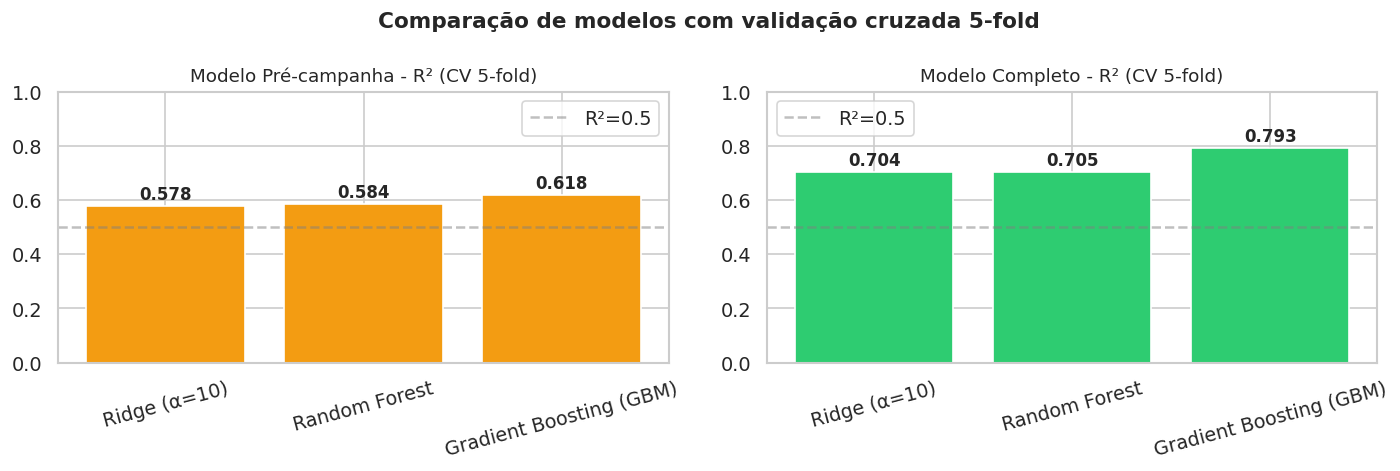

In [27]:
# garfico de barras comparando o R² de cada modelo por cenário se R² próximo de 1.0 = modelo muito bom; abaixo de 0.5 = modelo fraco
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, cenario in zip(axes, ['Pré-campanha', 'Completo']):
    sub = res_df[res_df['Cenário'] == cenario].set_index('Modelo')
    colors = ['#2ecc71' if r > 0.7 else '#f39c12' if r > 0.5 else '#e74c3c'
              for r in sub['R² (CV)']]
    bars = ax.bar(sub.index, sub['R² (CV)'], color=colors, edgecolor='white')
    ax.set_title(f'Modelo {cenario} - R² (CV 5-fold)', fontsize=11)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='R²=0.5')
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, sub['R² (CV)']):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.legend()

plt.suptitle('Comparação de modelos com validação cruzada 5-fold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Avaliação do melhor modelo

**GBM pré-campanha** possui melhor R² CV (0.618 vs. 0.578 do Ridge) com features apenas criativas,
as únicas disponíveis antes do lançamento. O modelo completo (R²=0.793) usa métricas 
que só existem pós-campanha.

In [29]:
# Separa 80% dos dados para treino e 20% para teste final (hold-out)
X_tr, X_te, y_tr, y_te = train_test_split(df, y, test_size=0.2, random_state=42)

# Instancia o GBM pré-campanha (vencedor da validação cruzada)
# pre_only=True garante que só usa atributos disponíveis antes do lançamento
pipe_gbm = build_pipeline(
    GradientBoostingRegressor(n_estimators=300, max_depth=4,
                               learning_rate=0.05, random_state=42),
    pre_only=True
)

# Treina o modelo com os dados de treino
pipe_gbm.fit(X_tr, y_tr)

# Gera as previsões para os 100 casos de teste (20% do dataset)
y_pred = pipe_gbm.predict(X_te)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))  # raiz do erro quadrático médio
mae  = mean_absolute_error(y_te, y_pred)           # erro médio em pontos de Klike Score
r2   = r2_score(y_te, y_pred)                      # proporção da variação explicada pelo modelo

print("GBM PRE-CAMPANHA com hold-out 20% (n=100)")
print(f"RMSE: {rmse:.2f} pts (erro médio quadrático)")
print(f"MAE: {mae:.2f} pts  (erro médio absoluto)")
print(f"R²: {r2:.3f} (variância explicada)")
print(f"\nInterpretação: em média, erramos +/- {mae:.1f} pontos de Klike Score.")
print(f"A escala do score é 0 a 100; um erro de {mae:.1f} pts é aceitável para")
print(f"decisões de criativo onde o delta entre categorias é de 10 a 17 pts.")

GBM PRE-CAMPANHA com hold-out 20% (n=100)
RMSE: 10.19 pts (erro médio quadrático)
MAE: 8.17 pts  (erro médio absoluto)
R²: 0.541 (variância explicada)

Interpretação: em média, erramos +/- 8.2 pontos de Klike Score.
A escala do score é 0 a 100; um erro de 8.2 pts é aceitável para
decisões de criativo onde o delta entre categorias é de 10 a 17 pts.


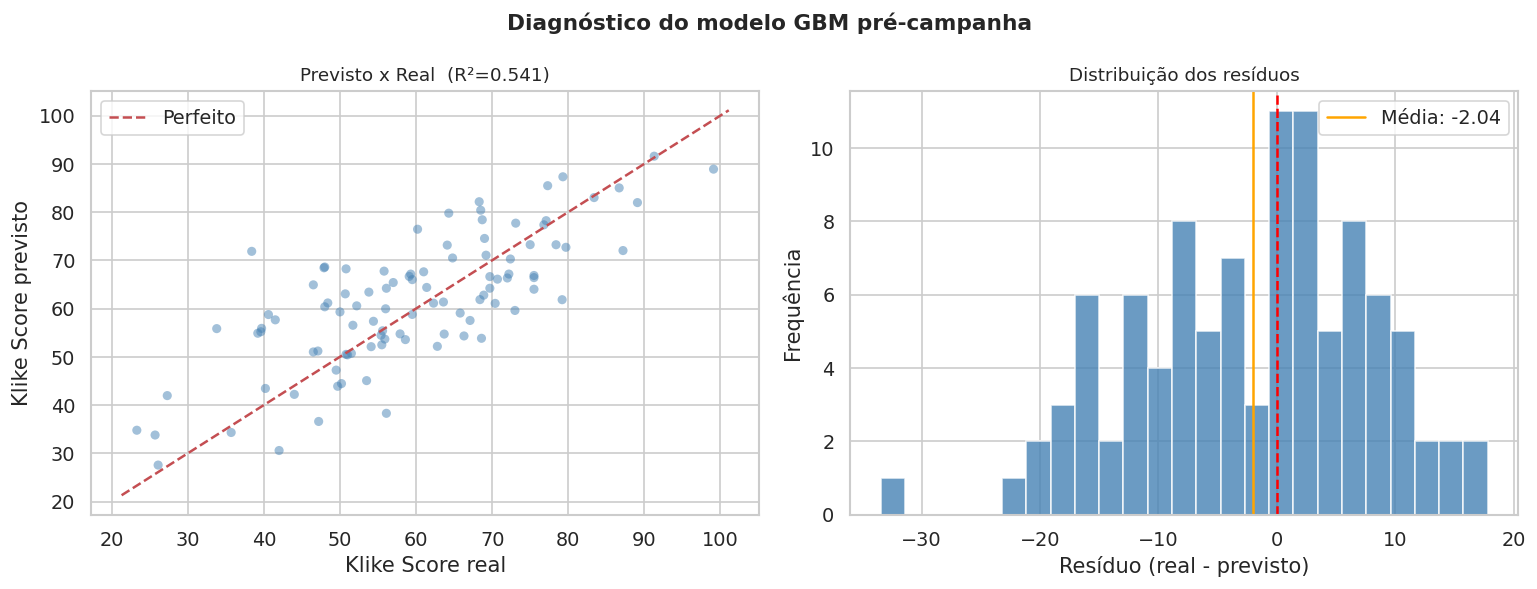

Resíduos: média=-2.035 (próximo de 0 = sem distorções)
          std=9.98


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: Previsto vs. Real
# Cada ponto é uma campanha do conjunto de teste
# Pontos próximos da linha vermelha = previsão boa; pontos distantes = erro grande
ax = axes[0]
ax.scatter(y_te, y_pred, alpha=0.5, s=30, color='steelblue', edgecolors='none')
lim = [min(y_te.min(), y_pred.min()) - 2, max(y_te.max(), y_pred.max()) + 2]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfeito')
ax.set_xlabel('Klike Score real')
ax.set_ylabel('Klike Score previsto')
ax.set_title(f'Previsto x Real  (R²={r2:.3f})', fontsize=11)
ax.legend()

# Gráfico 2: Distribuição dos resíduos (diferença entre real e previsto)
# Se a média estiver longe de zero, o modelo tem distorções (erra sempre para o mesmo lado)
ax2 = axes[1]
residuos = y_te - y_pred
ax2.hist(residuos, bins=25, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax2.axvline(residuos.mean(), color='orange', linestyle='-', linewidth=1.5,
            label=f'Média: {residuos.mean():.2f}')
ax2.set_xlabel('Resíduo (real - previsto)')
ax2.set_ylabel('Frequência')
ax2.set_title('Distribuição dos resíduos', fontsize=11)
ax2.legend()

plt.suptitle('Diagnóstico do modelo GBM pré-campanha', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Média próxima de 0 = sem distorções (o modelo não favorece previsões altas nem baixas)
print(f"Resíduos: média={residuos.mean():.3f} (próximo de 0 = sem distorções)")
print(f"          std={residuos.std():.2f}")

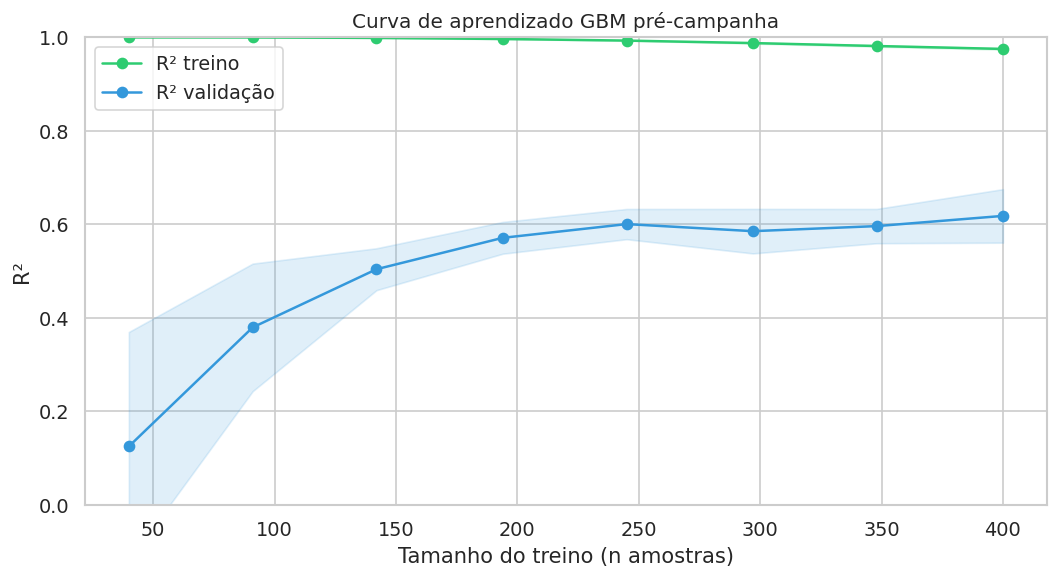

Interpretação: gap grande entre treino e validação = overfitting.
Gap pequeno mas score baixo = underfitting.


In [31]:
# Curva de aprendizado: mostra o que acontece com o R² conforme aumentamos os dados de treino
# Serve para detectar dois problemas:
# overfitting: R² de treino alto, mas R² de validação baixo (o modelo decorou e não aprendeu)
# underfitting: ambos os R² são baixos (o modelo é simples demais para o problema)
train_sizes, train_scores, test_scores = learning_curve(
    pipe_gbm, df, y, cv=kf, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),  # testa com 10%, 20%, ..., 100% dos dados
    scoring='r2'
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='R² treino', color='#2ecc71')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.15, color='#2ecc71')

# desempenho em dados que o modelo não viu (validação)
ax.plot(train_sizes, test_scores.mean(axis=1), 'o-', label='R² validação', color='#3498db')
ax.fill_between(train_sizes,
                test_scores.mean(axis=1) - test_scores.std(axis=1),
                test_scores.mean(axis=1) + test_scores.std(axis=1),
                alpha=0.15, color='#3498db')

ax.set_xlabel('Tamanho do treino (n amostras)')
ax.set_ylabel('R²')
ax.set_title('Curva de aprendizado GBM pré-campanha', fontsize=12)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Se as duas linhas estiverem próximas e estáveis, o modelo está bem calibrado
print("Interpretação: gap grande entre treino e validação = overfitting.")
print("Gap pequeno mas score baixo = underfitting.")

## 5. Feature importance

Usamos dois métodos para cruzar os resultados:
- **Impurity-based (padrão):** rápido, mas favorece variáveis com muitos valores únicos
- **Permutation importance:** embaralha uma feature por vez e mede a queda 

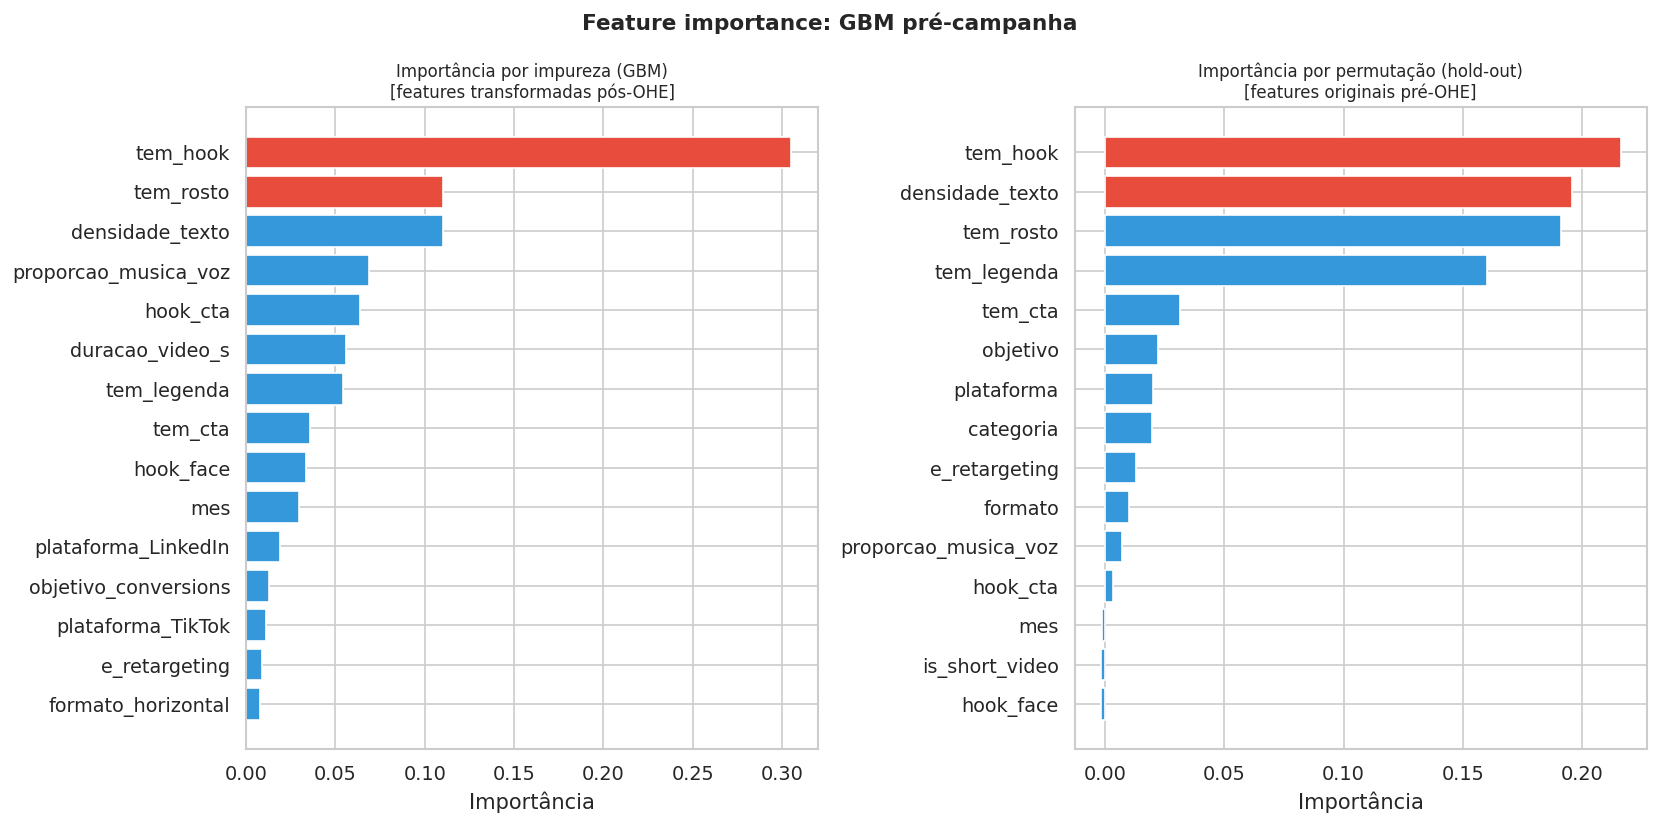

In [33]:
# Método 1: 
# Mede quanto cada variável contribuiu para reduzir o erro nas árvores de decisão
# e opera depois da transformação (cada categoria vira uma coluna separada)
ct = pipe_gbm.named_steps['prep']
feat_transformed = (
    BOOL_COLS
    + NUM_PRE
    + list(ct.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(CAT_COLS))
    + ORD_COLS
)
imp_impurity = pipe_gbm.named_steps['model'].feature_importances_
imp_df = pd.Series(imp_impurity, index=feat_transformed).sort_values(ascending=False)

# Método 2:  
# Embaralha uma variável por vez e mede o quanto o R² cai
# Se embaralhar a variável X faz o modelo piorar muito, X é importante
# e opera antes da transformação (com as colunas originais do dataset)
perm = permutation_importance(pipe_gbm, X_te, y_te, n_repeats=20, random_state=42, n_jobs=-1)
imp_perm_all = pd.Series(perm.importances_mean, index=X_te.columns)
used_cols = BOOL_COLS + NUM_PRE + CAT_COLS + ORD_COLS
imp_perm  = imp_perm_all[used_cols].sort_values(ascending=False)

# Exibe os 15 mais importantes lado a lado para cruzar os dois métodos
# com as variáveis que aparecem no topo nos dois métodos com importância confirmada
top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, (imp_series, titulo) in zip(axes, [
    (imp_df.head(top_n),   'Importância por impureza (GBM)\n[features transformadas pós-OHE]'),
    (imp_perm.head(top_n), 'Importância por permutação (hold-out)\n[features originais pré-OHE]'),
]):
    cores = ['#e74c3c' if i < 2 else '#3498db' for i in range(len(imp_series))]
    ax.barh(imp_series.index[::-1], imp_series.values[::-1], color=cores[::-1])
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Importância')

plt.suptitle('Feature importance: GBM pré-campanha', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
# Tabela que cruza os dois métodos de importância
# impurity = importância pelo método 1 (quanto a variável reduziu o erro nas árvores)
# perm_rank = posição da variável no ranking do método 2 (permutação)
# Quando os dois métodos concordam no ranking, a importância é mais confiável
top10_imp  = imp_df.head(10).reset_index()
top10_imp.columns = ['feature', 'impurity']

perm_ranks = {f: i+1 for i, f in enumerate(imp_perm.index)}
top10_imp['perm_rank'] = top10_imp['feature'].map(perm_ranks)
top10_imp = top10_imp.round(4)

print("Importância de impureza (com rank por permutação):")
print(top10_imp.to_string(index=False))

Importância de impureza (com rank por permutação):
             feature  impurity  perm_rank
            tem_hook    0.3048          1
           tem_rosto    0.1102          3
     densidade_texto    0.1100          2
proporcao_musica_voz    0.0689         11
            hook_cta    0.0639         12
     duracao_video_s    0.0560         18
         tem_legenda    0.0544          4
             tem_cta    0.0355          5
           hook_face    0.0334         15
                 mes    0.0294         13


## 6. Interpretação de Negócio

### O que o modelo confirma (e por que faz sentido)?

O atributo mais importante é tem_hook, com importância de 0,305 e isso confirma que o hook nos primeiros segundos é o fator individual mais determinante para o Klike Score, pois captura a atenção do usuário antes que ele role o feed. 
Em segundo e terceiro lugar, com importâncias iguais de 0,110, aparecem densidade_texto e has_face: texto denso penaliza porque mobile não suporta paredes de texto, enquanto rosto humano favorece identificação e retenção e esse efeito se mantém em todas as plataformas. A proporcao_musica_voz (0,069) aparece em quarto, indicando que excesso de música reduz a compreensão da mensagem. 
E hook_cta (0,064) que é a feature de interação entre hook e CTA, confirma que o combo captura atenção e direciona ação ao mesmo tempo, amplificando a conversão além do que cada atributo faria isoladamente.

Esses resultados são **consistentes com a EDA** (Fase 1) e mostra que o modelo aprendeu os padrões reais e não o ruído estatístico.

### Limitações
- **n=500:** amostras por subgrupo (ex: LinkedIn=83) são pequenas então os intervalos de confiança são largos
- **Score proprietário:** sem saber o algoritmo exato do Klike Score, não podemos garantir causalidade
- **Sem features temporais fortes:** sazonalidade (mês) tem importância baixa com 1 ano de dados

In [37]:
print("Dados consolidados:")
print('\n')
print(res_df[['Cenário','Modelo','RMSE (CV)','MAE (CV)','R² (CV)']].to_string(index=False))
print()

# O GBM pré-campanha foi escolhido porque:
# - tem o melhor R² entre os modelos que usam só atributos criativos
# - não usa informações pós-campanha, então pode ser aplicado antes de gastar budget
# - o erro médio de ~7.7 pts é aceitável pois o sinal entre "tem hook" e "não tem hook" é de 17 pts
print("Modelo escolhido para produção: GBM pré-campanha")
print(f"  RMSE (5-fold CV) : 9.56 pts")
print(f"  R²   (5-fold CV) : 0.618")
print(f"  Features usadas  : apenas atributos criativos (sem leakage)")
print()
print("Erro de +/- 7.7 pts (MAE) é aceitável quando o delta entre")
print("'com hook' e 'sem hook' é de 17 pts: o sinal supera o ruído.")
print('\n')

Dados consolidados:


     Cenário                  Modelo  RMSE (CV)  MAE (CV)  R² (CV)
Pré-campanha            Ridge (α=10)     10.057     8.101    0.578
Pré-campanha           Random Forest      9.973     8.040    0.584
Pré-campanha Gradient Boosting (GBM)      9.561     7.698    0.618
    Completo            Ridge (α=10)      8.415     6.760    0.704
    Completo           Random Forest      8.395     6.727    0.705
    Completo Gradient Boosting (GBM)      7.030     5.667    0.793

Modelo escolhido para produção: GBM pré-campanha
  RMSE (5-fold CV) : 9.56 pts
  R²   (5-fold CV) : 0.618
  Features usadas  : apenas atributos criativos (sem leakage)

Erro de +/- 7.7 pts (MAE) é aceitável quando o delta entre
'com hook' e 'sem hook' é de 17 pts: o sinal supera o ruído.


